# ETAPE 4 — Exploration des données
**Projet : Optimisation du Réseau de Boutiques TELECOM — Groupe 5 SUD-EST**

---
### Plan d'analyse
- **4a** Analyse univariée — variable par variable
- **4b** Analyse bivariée — croisements métier
- **4c** Analyse temporelle — évolution N vs N-1
- **4d** Analyse spatiale — focus géographique SUD-EST

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('base_travail_SUD_EST.csv', low_memory=False, parse_dates=['PERIOD'])
print(f"Dataset chargé : {len(df):,} lignes x {df.shape[1]} colonnes")
df.head(2)

Dataset chargé : 226,677 lignes x 21 colonnes


,LINE_TYPE,PERIOD_YYYY,PERIOD_MM,ORDER_SHOP_CD,PERSON_SALUTATION_CD,PERSON_BIRTH_DT_year,NET_ZONE_IN,DENSE_ZONE_IN,DEPRTMNT_ID,CITY_LN,...,Geolife,GEOLIFE_AGG,PERIOD,birth_decade,age_client,Surface_COMMERC,Emplacement_PDV,latitude,longitude,MKT_CHANNL_LB
0,T,2022,11,VADPCM,M,1980-1989,0.0,0.0,20,ROSAZIA,...,11A_saisonnier,Résidence secondaire,2022-11-01,1980.0,39.0,NaN,NaN,NaN,NaN,NaN
1,I,2022,12,04PHSESIST,M,1940-1949,1.0,0.0,04,ST ETIENNE LES ORGUES,...,11C_tourisme vert,Résidence secondaire,2022-12-01,1940.0,79.0,42.0,CV,44.196507,5.942554,Réseau Partenaire


---
## 4a — Analyse univariée

### LINE_TYPE — Répartition des types de produits

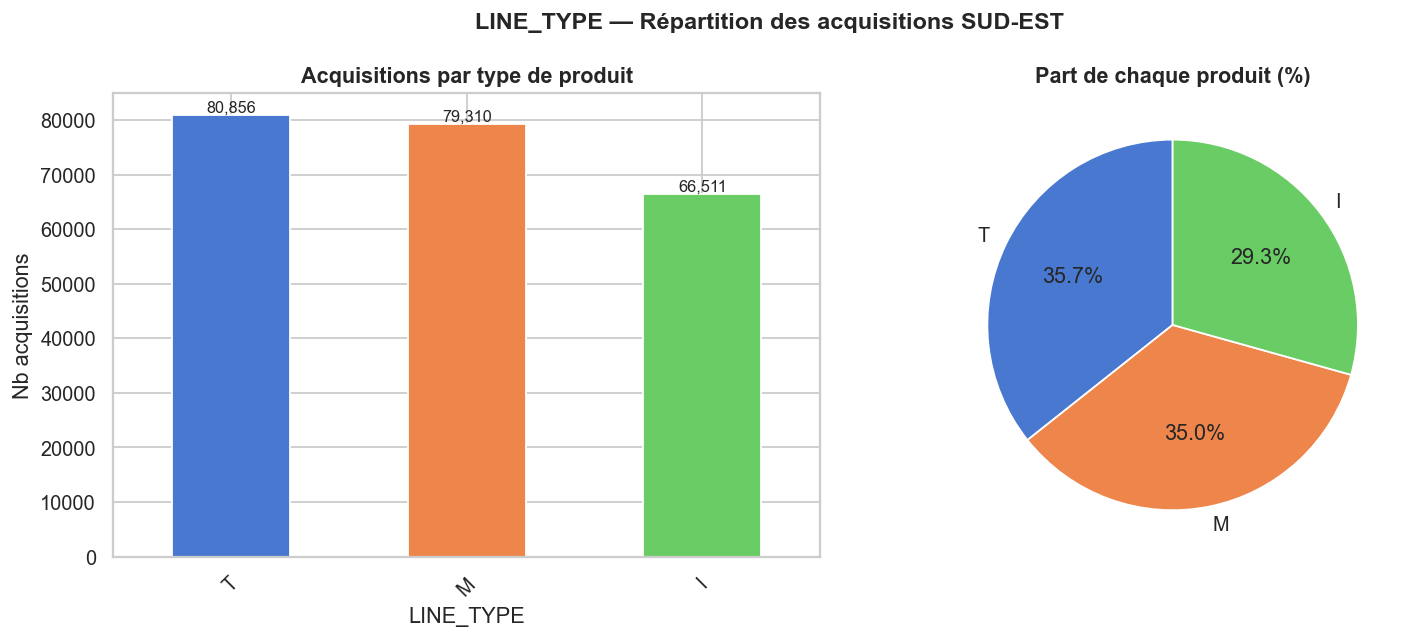

LINE_TYPE
T    35.7
M    35.0
I    29.3


In [9]:
lt_counts = df['LINE_TYPE'].value_counts()
lt_pct = lt_counts / lt_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barres
lt_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(lt_counts)))
axes[0].set_title('Acquisitions par type de produit', fontweight='bold')
axes[0].set_xlabel('LINE_TYPE')
axes[0].set_ylabel('Nb acquisitions')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Camembert
axes[1].pie(lt_pct, labels=lt_pct.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted', len(lt_counts)))
axes[1].set_title('Part de chaque produit (%)', fontweight='bold')

plt.suptitle('LINE_TYPE — Répartition des acquisitions SUD-EST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('4a_line_type.png', bbox_inches='tight')
plt.show()
print(lt_pct.round(1).to_string())

### PERIOD — Evolution temporelle des acquisitions

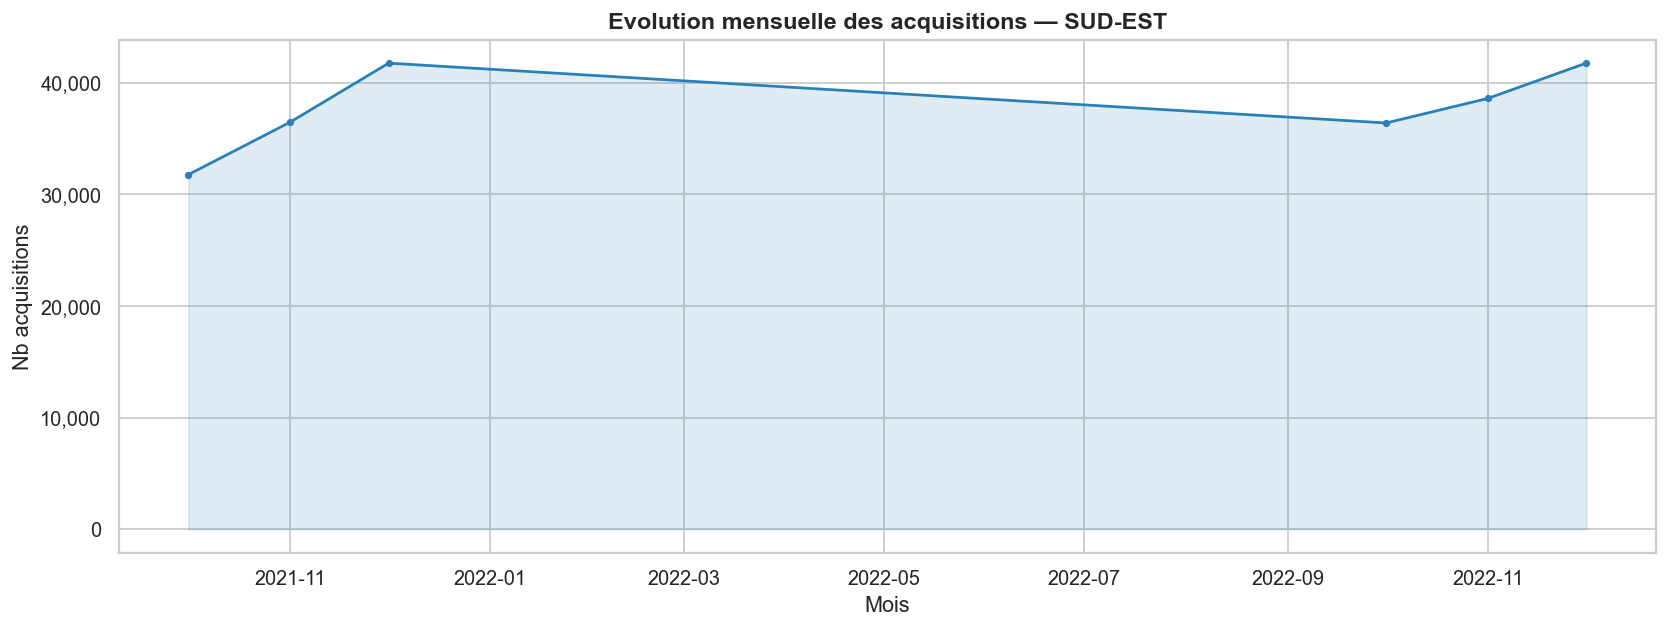


Acquisitions par année :
PERIOD_YYYY
2021    109967
2022    116710


In [10]:
monthly = df.groupby('PERIOD').size().reset_index(name='acquisitions')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly['PERIOD'], monthly['acquisitions'], marker='o', markersize=3, linewidth=1.5, color='#2980b9')
ax.fill_between(monthly['PERIOD'], monthly['acquisitions'], alpha=0.15, color='#2980b9')
ax.set_title('Evolution mensuelle des acquisitions — SUD-EST', fontweight='bold', fontsize=13)
ax.set_xlabel('Mois')
ax.set_ylabel('Nb acquisitions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('4a_period.png', bbox_inches='tight')
plt.show()

print("\nAcquisitions par année :")
print(df.groupby('PERIOD_YYYY').size().to_string())

### ORDER_SHOP_CD — Top et Flop boutiques

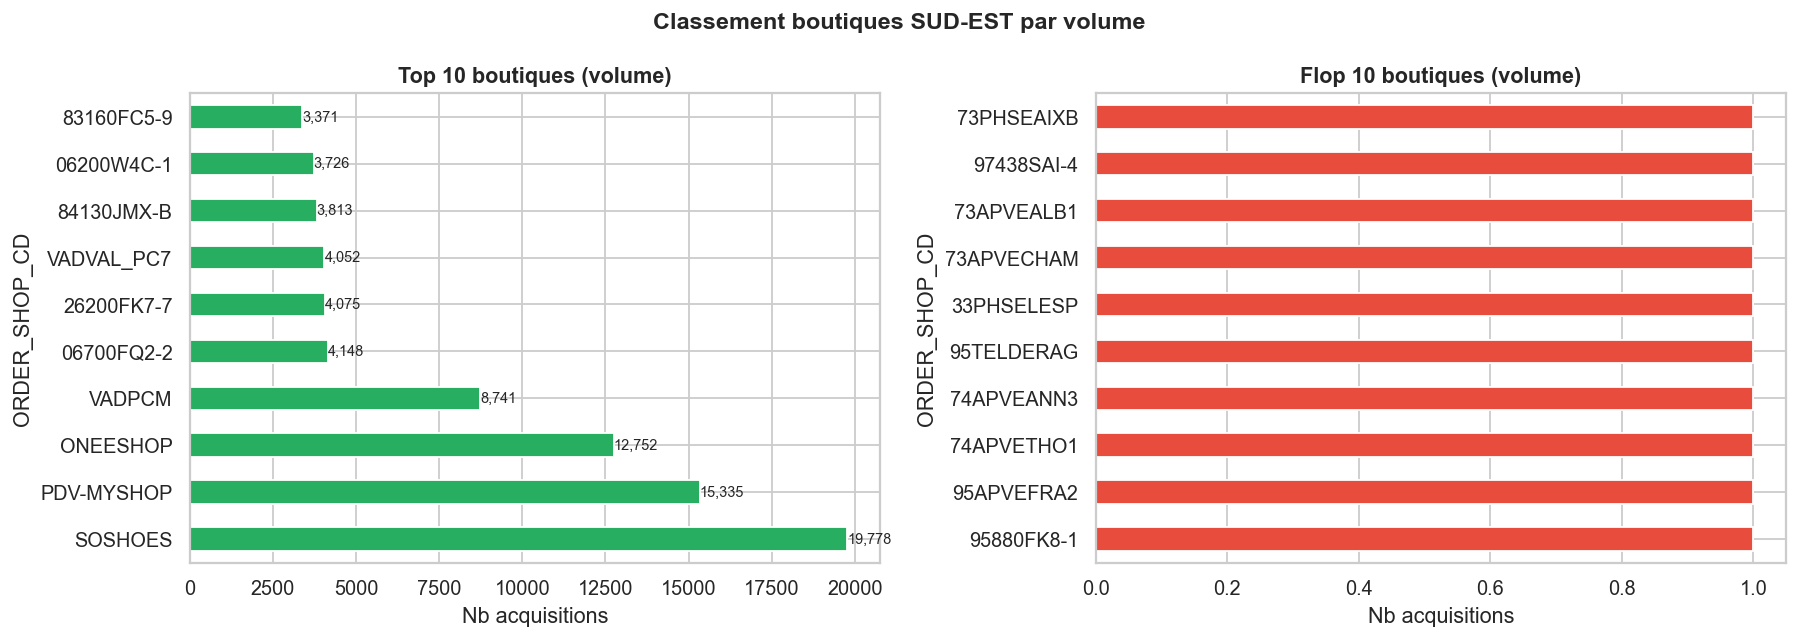


Stats volume par boutique :
count     1068
mean       212
std       1030
min          1
25%          2
50%          8
75%         29
max      19778
dtype: Int64


In [11]:
shop_vol = df.groupby('ORDER_SHOP_CD').size().sort_values(ascending=False)
top10 = shop_vol.head(10)
flop10 = shop_vol.tail(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10.plot(kind='barh', ax=axes[0], color='#27ae60')
axes[0].set_title('Top 10 boutiques (volume)', fontweight='bold')
axes[0].set_xlabel('Nb acquisitions')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height()/2),
                     va='center', ha='left', fontsize=8)

flop10.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Flop 10 boutiques (volume)', fontweight='bold')
axes[1].set_xlabel('Nb acquisitions')

plt.suptitle('Classement boutiques SUD-EST par volume', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('4a_boutiques_classement.png', bbox_inches='tight')
plt.show()

print(f"\nStats volume par boutique :")
print(shop_vol.describe().round(0).astype('Int64'))

### PERSON_BIRTH_DT_year — Tranches d'âge

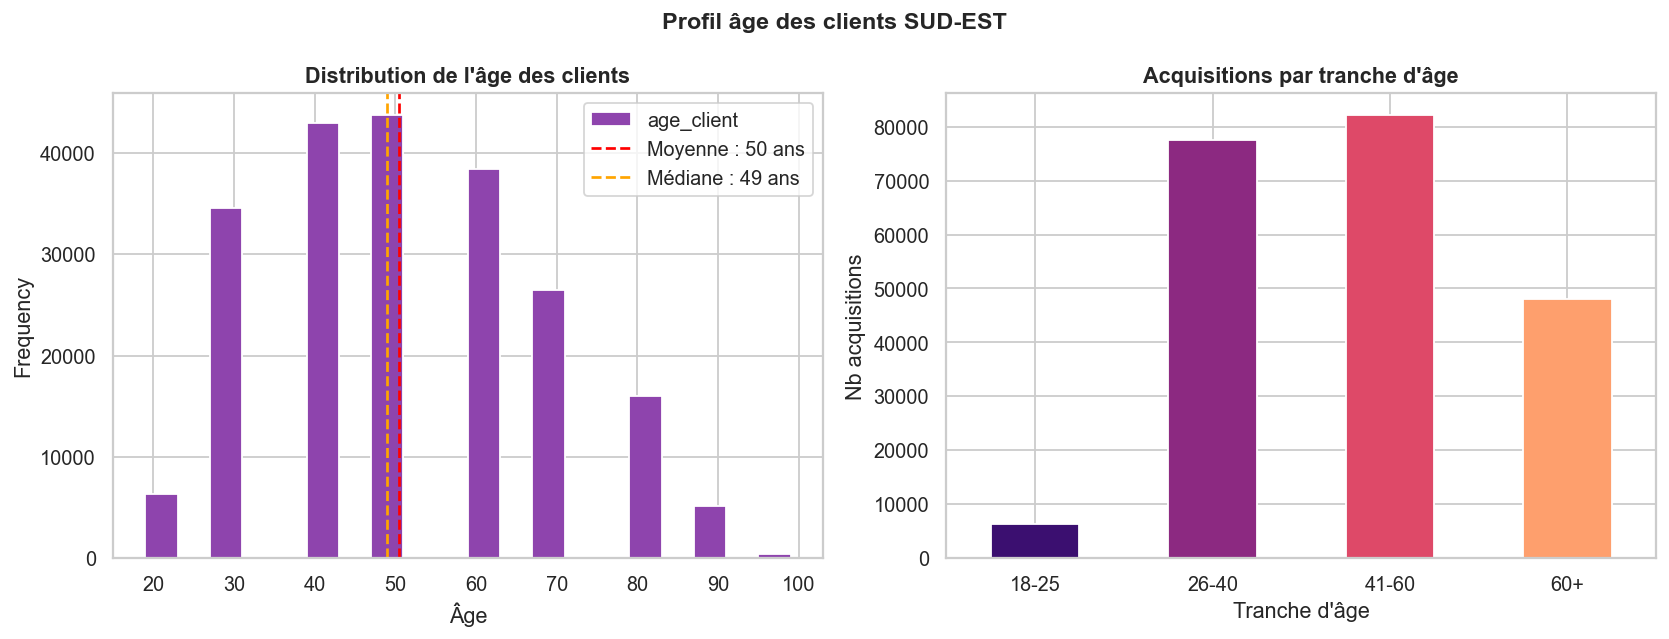

Âge moyen : 50.4 ans | Médiane : 49.0 ans


In [12]:
# Calculer l'âge si pas déjà présent
if 'age_client' not in df.columns:
    def parse_decade(val):
        try:
            return int(str(val).split('-')[0])
        except:
            return np.nan
    df['birth_decade'] = df['PERSON_BIRTH_DT_year'].apply(parse_decade)
    df['age_client'] = 2024 - (df['birth_decade'] + 5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme
df['age_client'].dropna().plot(kind='hist', bins=20, ax=axes[0], color='#8e44ad', edgecolor='white')
axes[0].axvline(df['age_client'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['age_client'].mean():.0f} ans")
axes[0].axvline(df['age_client'].median(), color='orange', linestyle='--', label=f"Médiane : {df['age_client'].median():.0f} ans")
axes[0].set_title('Distribution de l\'âge des clients', fontweight='bold')
axes[0].set_xlabel('Âge')
axes[0].legend()

# Tranches
bins = [0, 25, 40, 60, 100]
labels = ['18-25', '26-40', '41-60', '60+']
df['tranche_age'] = pd.cut(df['age_client'], bins=bins, labels=labels)
tranche_counts = df['tranche_age'].value_counts().sort_index()
tranche_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('magma', 4))
axes[1].set_title('Acquisitions par tranche d\'âge', fontweight='bold')
axes[1].set_xlabel('Tranche d\'âge')
axes[1].set_ylabel('Nb acquisitions')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Profil âge des clients SUD-EST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('4a_age.png', bbox_inches='tight')
plt.show()

print(f"Âge moyen : {df['age_client'].mean():.1f} ans | Médiane : {df['age_client'].median():.1f} ans")

### Geolife — Segments socio-démographiques

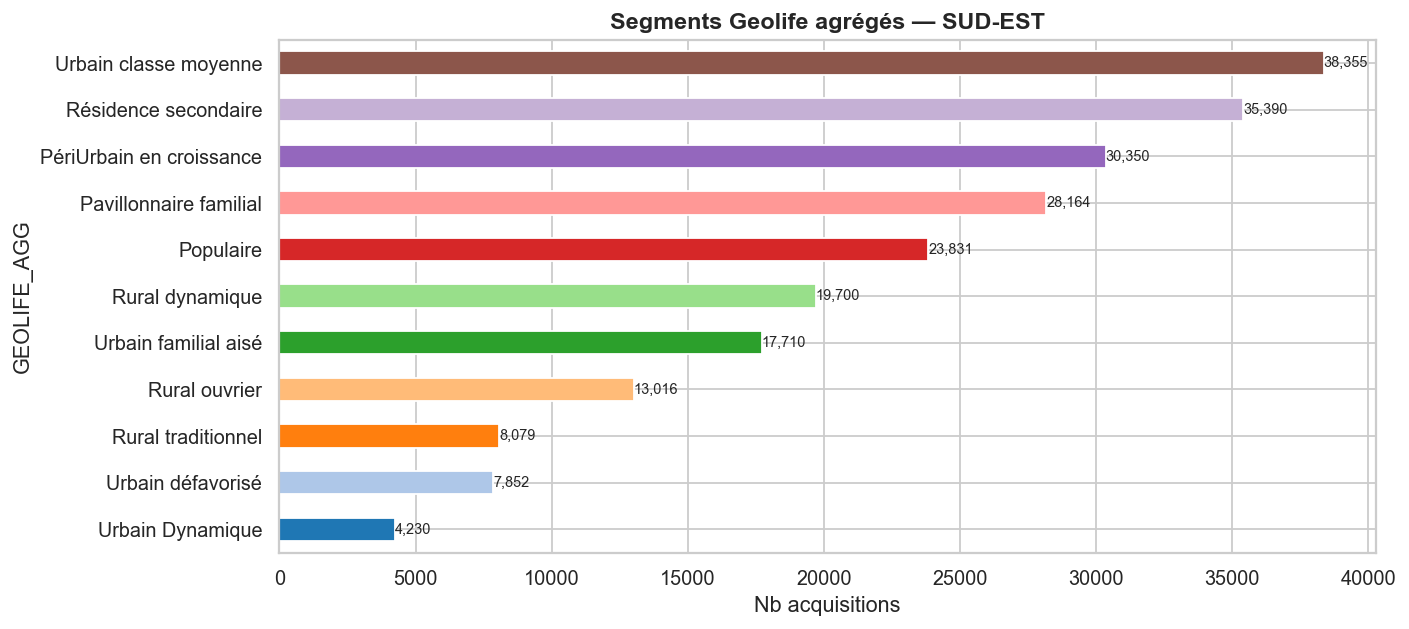

In [13]:
geo_counts = df['GEOLIFE_AGG'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 5))
geo_counts.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('tab20', len(geo_counts)))
ax.set_title('Segments Geolife agrégés — SUD-EST', fontweight='bold', fontsize=13)
ax.set_xlabel('Nb acquisitions')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height()/2),
                va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.savefig('4a_geolife.png', bbox_inches='tight')
plt.show()

### Emplacement & Surface — Profil des boutiques

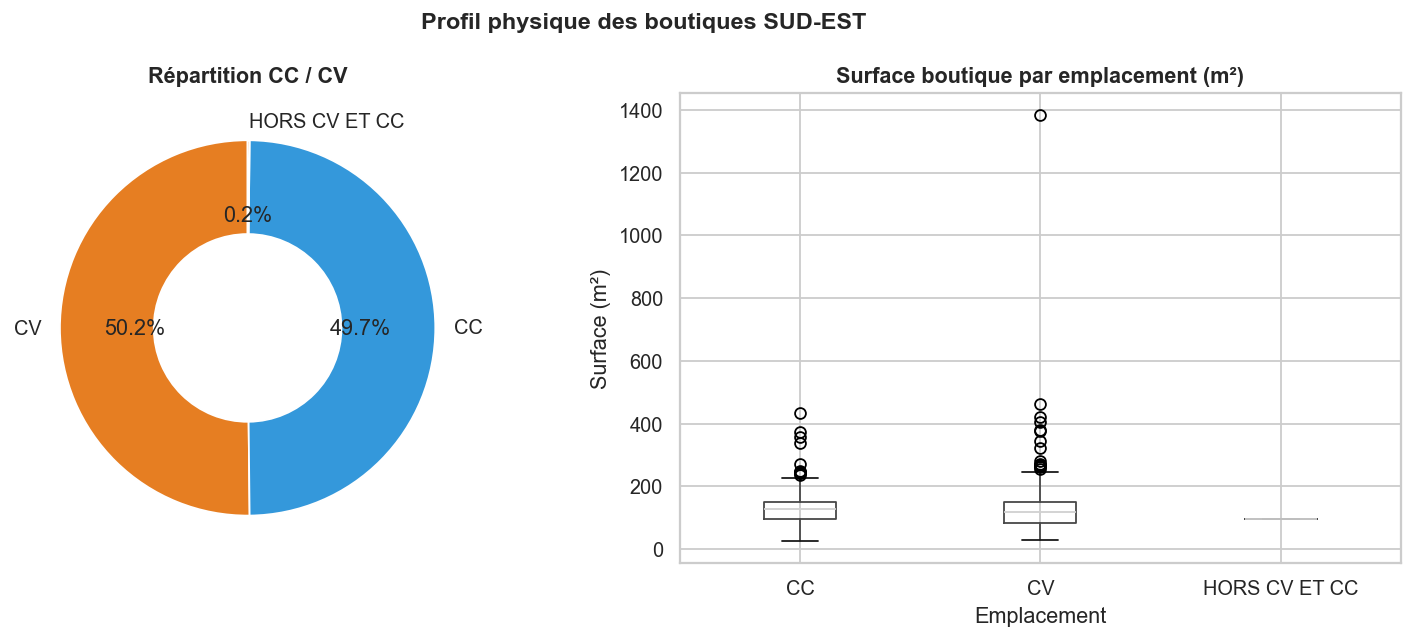


Stats surface (m²) par emplacement :
                 count  mean   std  min  25%  50%  75%   max
Emplacement_PDV                                             
CC                 292   130    51   25   97  129  151   435
CV                 295   131    98   28   84  118  151  1385
HORS CV ET CC        1    97  <NA>   97   97   97   97    97


In [14]:
boutiques = df.drop_duplicates('ORDER_SHOP_CD')[['ORDER_SHOP_CD', 'Emplacement_PDV', 'Surface_COMMERC']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut CC vs CV
emp = boutiques['Emplacement_PDV'].value_counts()
axes[0].pie(emp, labels=emp.index, autopct='%1.1f%%', startangle=90,
            colors=['#e67e22', '#3498db'], wedgeprops={'width': 0.5})
axes[0].set_title('Répartition CC / CV', fontweight='bold')

# Boxplot surface
boutiques.boxplot(column='Surface_COMMERC', by='Emplacement_PDV', ax=axes[1])
axes[1].set_title('Surface boutique par emplacement (m²)', fontweight='bold')
axes[1].set_xlabel('Emplacement')
axes[1].set_ylabel('Surface (m²)')
plt.suptitle('')

plt.suptitle('Profil physique des boutiques SUD-EST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('4a_emplacement_surface.png', bbox_inches='tight')
plt.show()

print("\nStats surface (m²) par emplacement :")
print(boutiques.groupby('Emplacement_PDV')['Surface_COMMERC'].describe().round(0).astype('Int64'))

---
## 4b — Analyse bivariée

### LINE_TYPE × PERIOD — Évolution des produits dans le temps

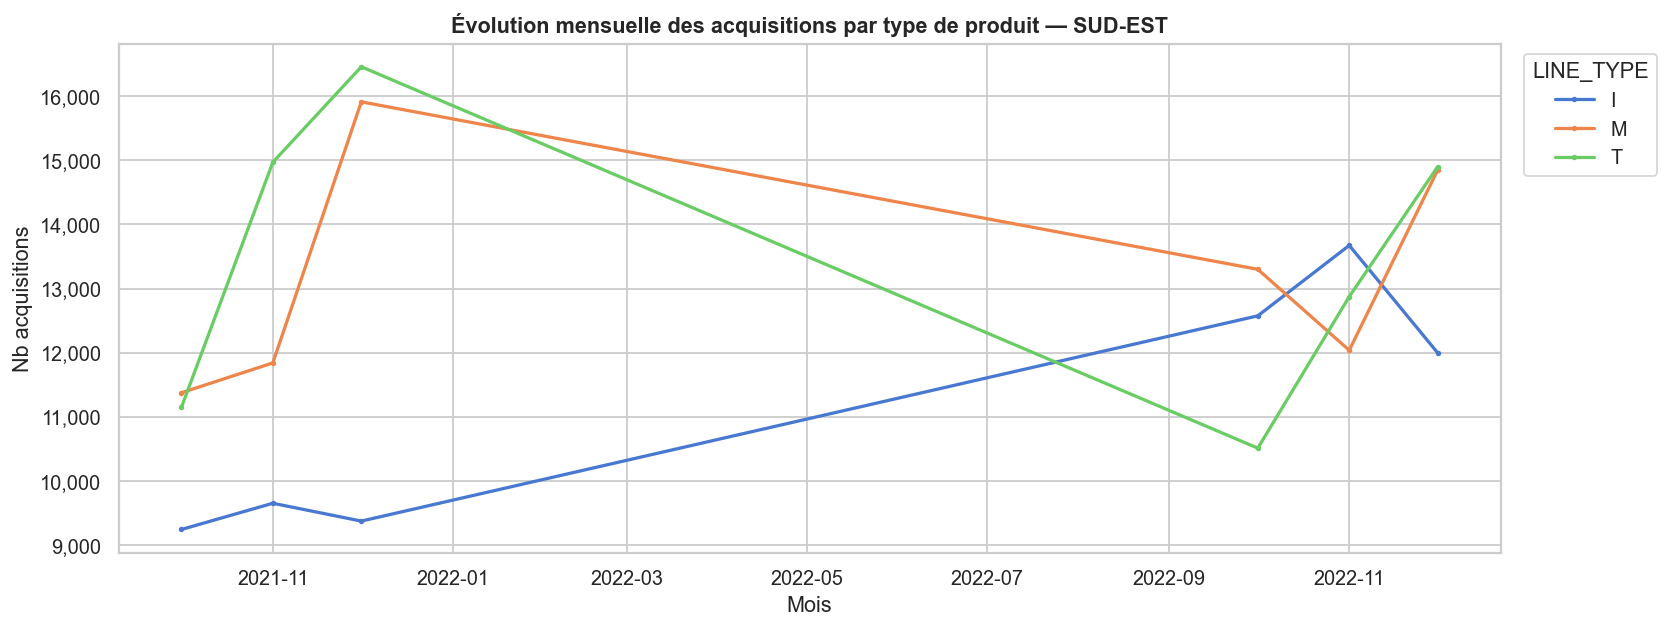

In [15]:
lt_period = df.groupby(['PERIOD', 'LINE_TYPE']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
for col in lt_period.columns:
    ax.plot(lt_period.index, lt_period[col], label=col, linewidth=1.8, marker='o', markersize=2)

ax.set_title('Évolution mensuelle des acquisitions par type de produit — SUD-EST', fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Nb acquisitions')
ax.legend(title='LINE_TYPE', bbox_to_anchor=(1.01, 1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('4b_linetype_period.png', bbox_inches='tight')
plt.show()

### Geolife × LINE_TYPE — Quels profils clients achètent quoi ?

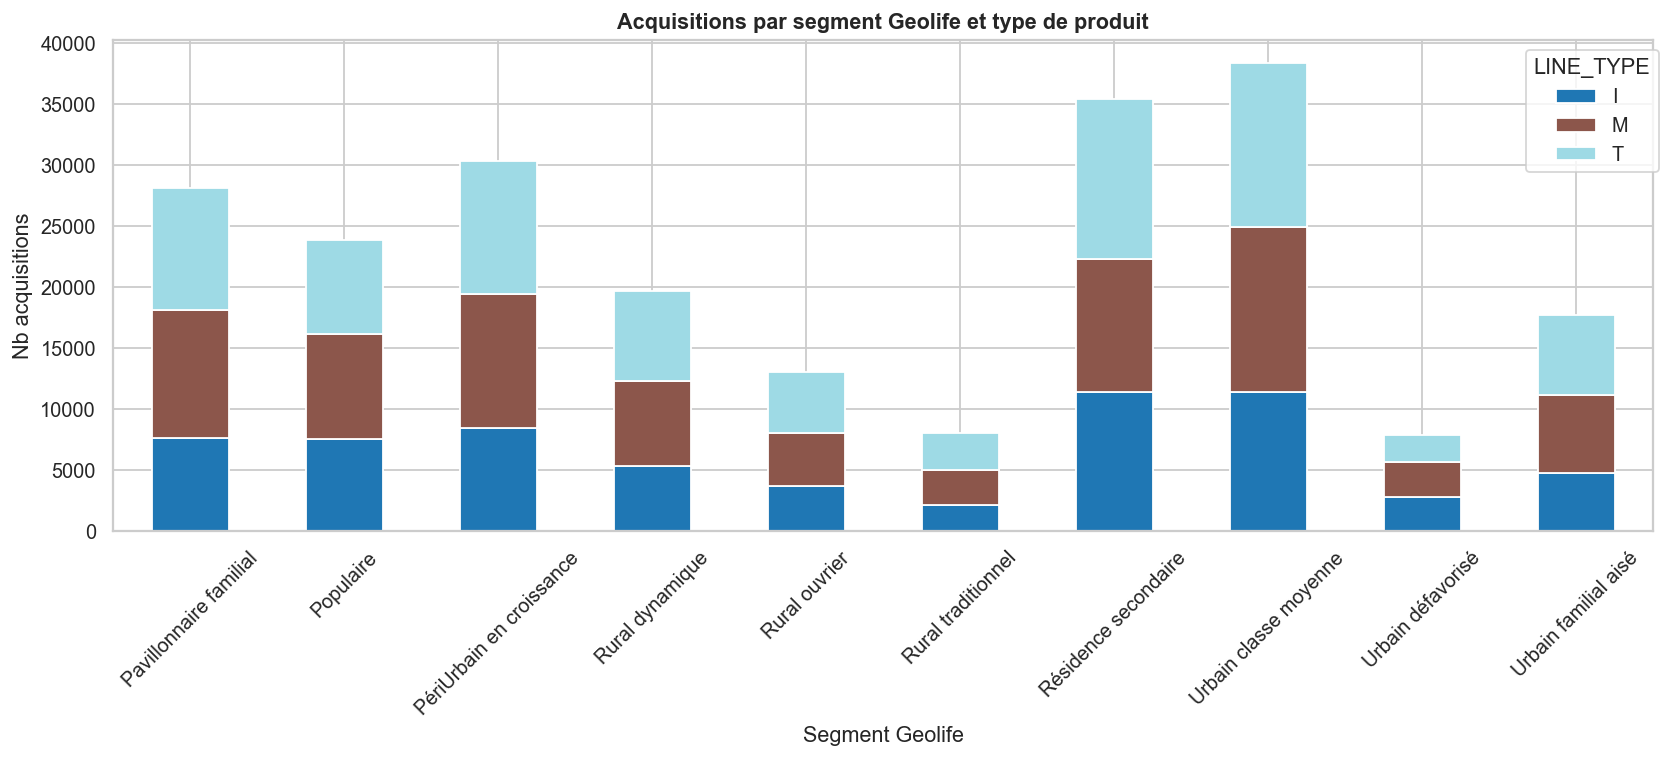

In [16]:
geo_lt = df.groupby(['GEOLIFE_AGG', 'LINE_TYPE']).size().unstack(fill_value=0)
# Garder top 10 segments
top_geo = df['GEOLIFE_AGG'].value_counts().head(10).index
geo_lt = geo_lt.loc[geo_lt.index.isin(top_geo)]

fig, ax = plt.subplots(figsize=(13, 6))
geo_lt.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Acquisitions par segment Geolife et type de produit', fontweight='bold')
ax.set_xlabel('Segment Geolife')
ax.set_ylabel('Nb acquisitions')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='LINE_TYPE', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('4b_geolife_linetype.png', bbox_inches='tight')
plt.show()

### Surface × Volume — Les grandes boutiques vendent-elles plus ?

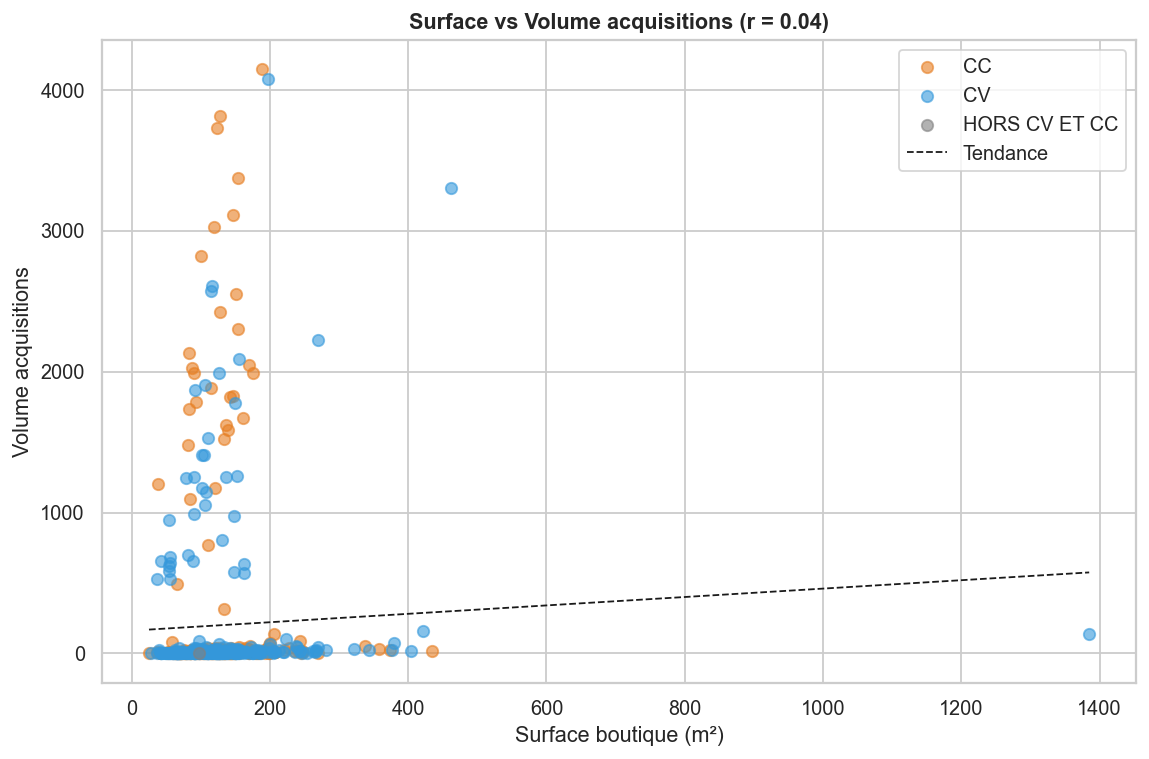

Corrélation Surface / Volume : 0.038


In [17]:
shop_stats = df.groupby('ORDER_SHOP_CD').agg(
    volume=('LINE_TYPE', 'count'),
    surface=('Surface_COMMERC', 'first'),
    emplacement=('Emplacement_PDV', 'first')
).dropna()

fig, ax = plt.subplots(figsize=(9, 6))
colors = {'CC': '#e67e22', 'CV': '#3498db'}
for emp, grp in shop_stats.groupby('emplacement'):
    ax.scatter(grp['surface'], grp['volume'], label=emp, alpha=0.6, s=40, color=colors.get(emp, 'gray'))

# Ligne de tendance
mask = shop_stats[['surface', 'volume']].dropna()
z = np.polyfit(mask['surface'], mask['volume'], 1)
p = np.poly1d(z)
x_range = np.linspace(mask['surface'].min(), mask['surface'].max(), 100)
ax.plot(x_range, p(x_range), 'k--', linewidth=1, label='Tendance')

corr = mask.corr().loc['surface', 'volume']
ax.set_title(f'Surface vs Volume acquisitions (r = {corr:.2f})', fontweight='bold')
ax.set_xlabel('Surface boutique (m²)')
ax.set_ylabel('Volume acquisitions')
ax.legend()
plt.tight_layout()
plt.savefig('4b_surface_volume.png', bbox_inches='tight')
plt.show()
print(f"Corrélation Surface / Volume : {corr:.3f}")

### Emplacement × Volume — CC ou CV plus performant ?

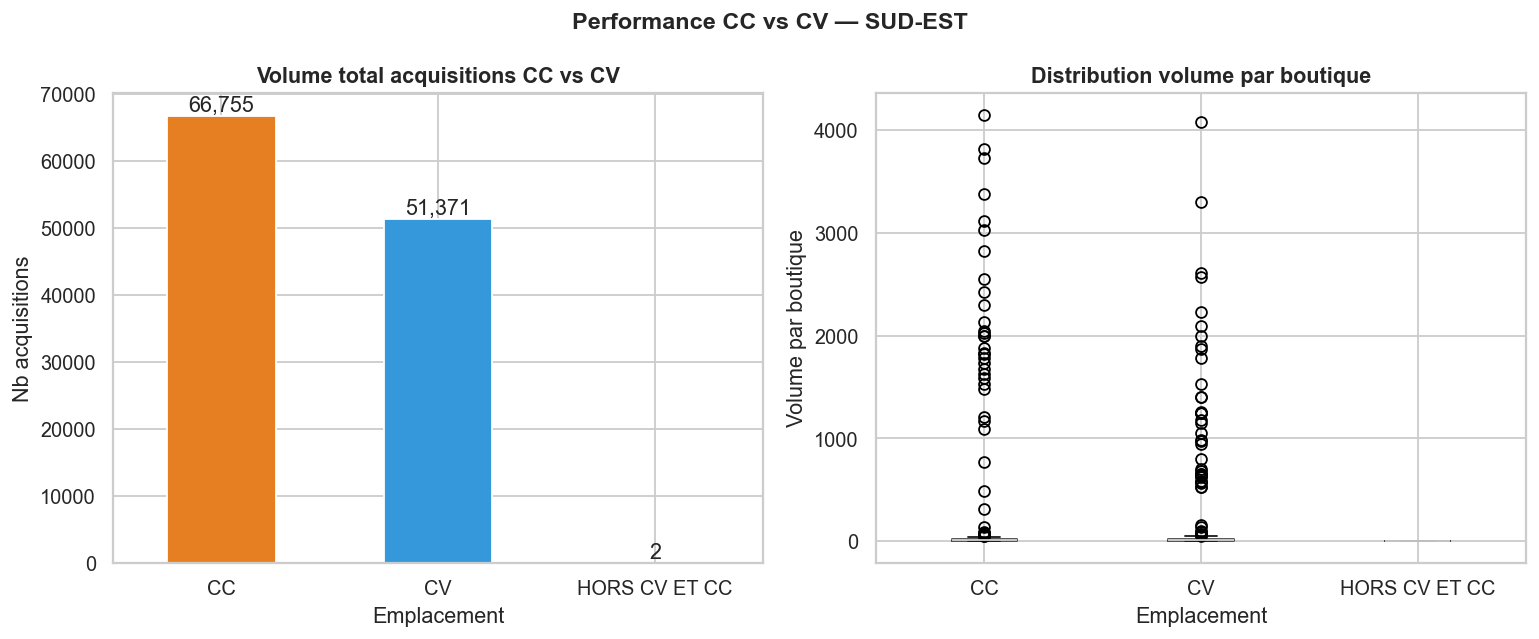

Volume moyen par boutique :
                 mean  median    sum
Emplacement_PDV                     
CC                229      10  66755
CV                174       8  51371
HORS CV ET CC       2       2      2


In [18]:
vol_emp = df.groupby(['ORDER_SHOP_CD', 'Emplacement_PDV']).size().reset_index(name='volume')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Volume total par type
vol_emp.groupby('Emplacement_PDV')['volume'].sum().plot(kind='bar', ax=axes[0],
    color=['#e67e22', '#3498db'])
axes[0].set_title('Volume total acquisitions CC vs CV', fontweight='bold')
axes[0].set_xlabel('Emplacement')
axes[0].set_ylabel('Nb acquisitions')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

# Volume médian par boutique
vol_emp.boxplot(column='volume', by='Emplacement_PDV', ax=axes[1])
axes[1].set_title('Distribution volume par boutique', fontweight='bold')
axes[1].set_xlabel('Emplacement')
axes[1].set_ylabel('Volume par boutique')
plt.suptitle('')

plt.suptitle('Performance CC vs CV — SUD-EST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('4b_cc_cv.png', bbox_inches='tight')
plt.show()

print("Volume moyen par boutique :")
print(vol_emp.groupby('Emplacement_PDV')['volume'].agg(['mean', 'median', 'sum']).round(0).astype('Int64'))

---
## 4c — Analyse temporelle : N vs N-1

In [19]:
# Volume par boutique et par année
vol_year = df.groupby(['ORDER_SHOP_CD', 'PERIOD_YYYY']).size().unstack(fill_value=0)
print("Années disponibles :", vol_year.columns.tolist())
vol_year.head(3)

Années disponibles : [2021, 2022]


PERIOD_YYYY,2021,2022
ORDER_SHOP_CD,,
01011FG1-6,7,7
01100FG1-7,7,4
01210FV3-1,24,15



Comparaison 2021 vs 2022 — Répartition des boutiques :
tendance
Déclin fort         375
Forte croissance    307
Stable              102
Croissance           48
Déclin               38
Name: count, dtype: int64


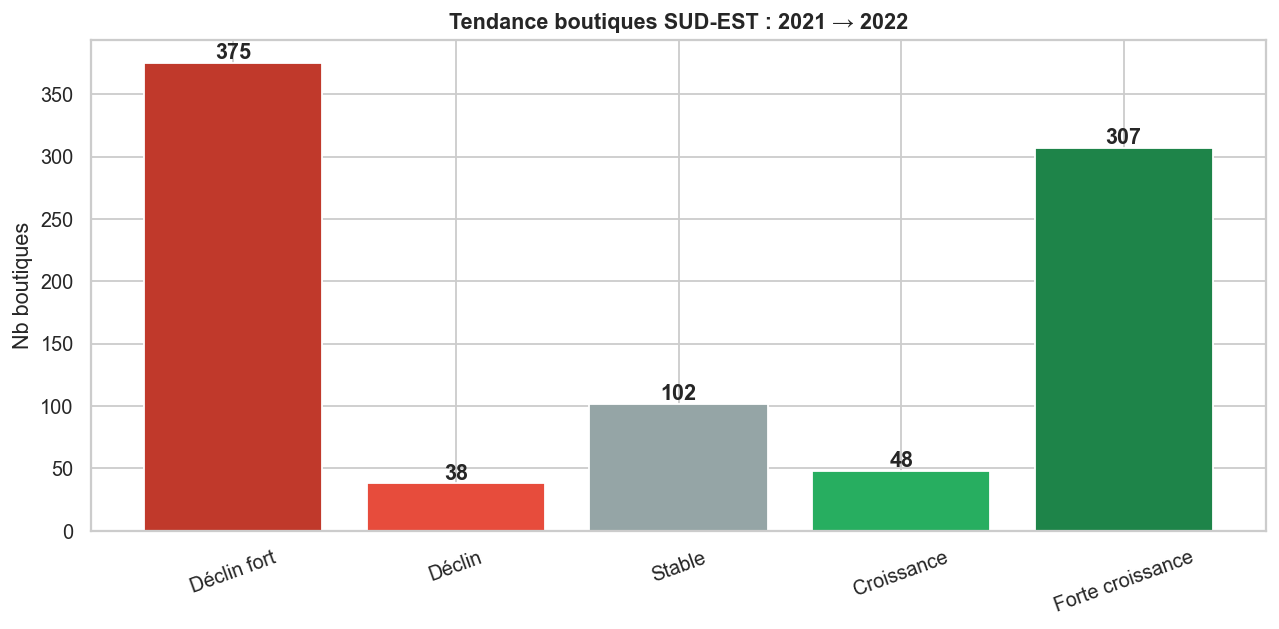

In [20]:
# Prendre les 2 dernières années disponibles
years = sorted(vol_year.columns.tolist())
if len(years) >= 2:
    yr_n1, yr_n = years[-2], years[-1]
    
    vol_year['croissance_yoy'] = (
        (vol_year[yr_n] - vol_year[yr_n1]) / vol_year[yr_n1].replace(0, np.nan) * 100
    ).round(1)
    
    vol_year['tendance'] = pd.cut(
        vol_year['croissance_yoy'],
        bins=[-np.inf, -20, -5, 5, 15, np.inf],
        labels=['Déclin fort', 'Déclin', 'Stable', 'Croissance', 'Forte croissance']
    )
    
    print(f"\nComparaison {yr_n1} vs {yr_n} — Répartition des boutiques :")
    print(vol_year['tendance'].value_counts())
    
    # Graphique
    fig, ax = plt.subplots(figsize=(10, 5))
    tend_colors = {'Déclin fort': '#c0392b', 'Déclin': '#e74c3c', 'Stable': '#95a5a6',
                   'Croissance': '#27ae60', 'Forte croissance': '#1e8449'}
    tend_counts = vol_year['tendance'].value_counts().sort_index()
    bars = ax.bar(tend_counts.index, tend_counts.values,
                  color=[tend_colors[t] for t in tend_counts.index])
    ax.set_title(f'Tendance boutiques SUD-EST : {yr_n1} → {yr_n}', fontweight='bold')
    ax.set_ylabel('Nb boutiques')
    ax.tick_params(axis='x', rotation=20)
    for b in bars:
        ax.annotate(str(int(b.get_height())), (b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.savefig('4c_croissance_yoy.png', bbox_inches='tight')
    plt.show()
else:
    print("Une seule année disponible — analyse N vs N-1 impossible")

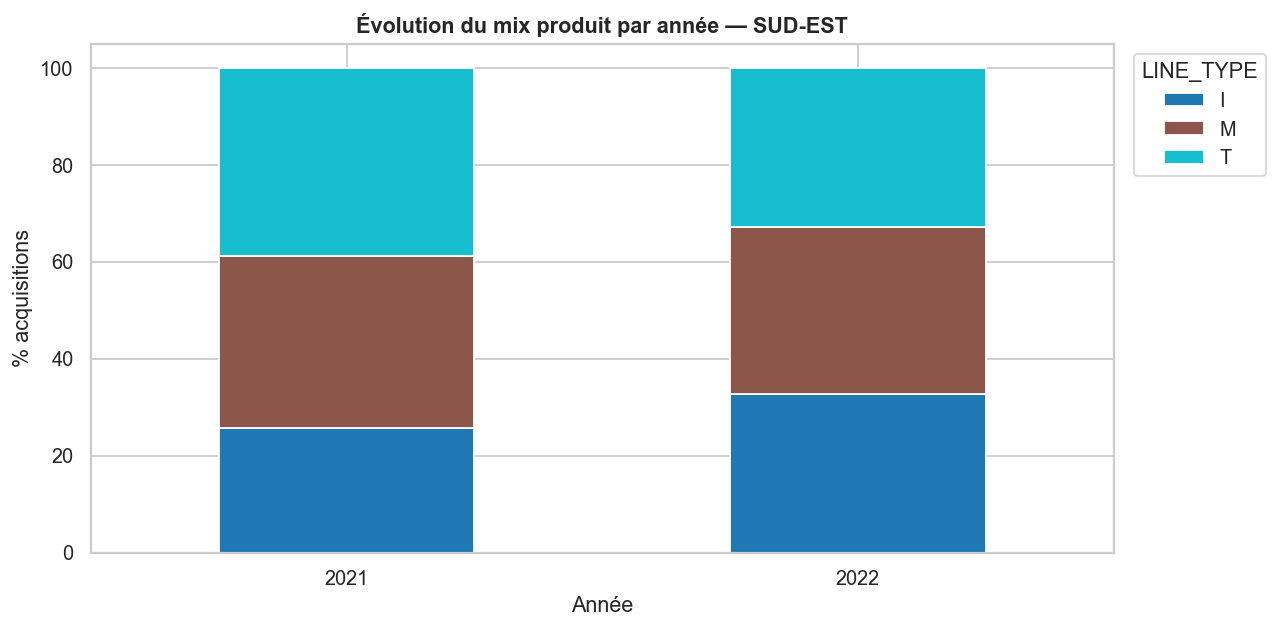

LINE_TYPE       I     M     T
PERIOD_YYYY                  
2021         25.7  35.6  38.7
2022         32.8  34.4  32.8


In [21]:
# Mix produit par année
mix = df.groupby(['PERIOD_YYYY', 'LINE_TYPE']).size().unstack(fill_value=0)
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
mix_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Évolution du mix produit par année — SUD-EST', fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('% acquisitions')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='LINE_TYPE', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('4c_mix_produit.png', bbox_inches='tight')
plt.show()
print(mix_pct.round(1).to_string())

---
## 4d — Analyse spatiale SUD-EST

Boutiques avec coordonnées : 588


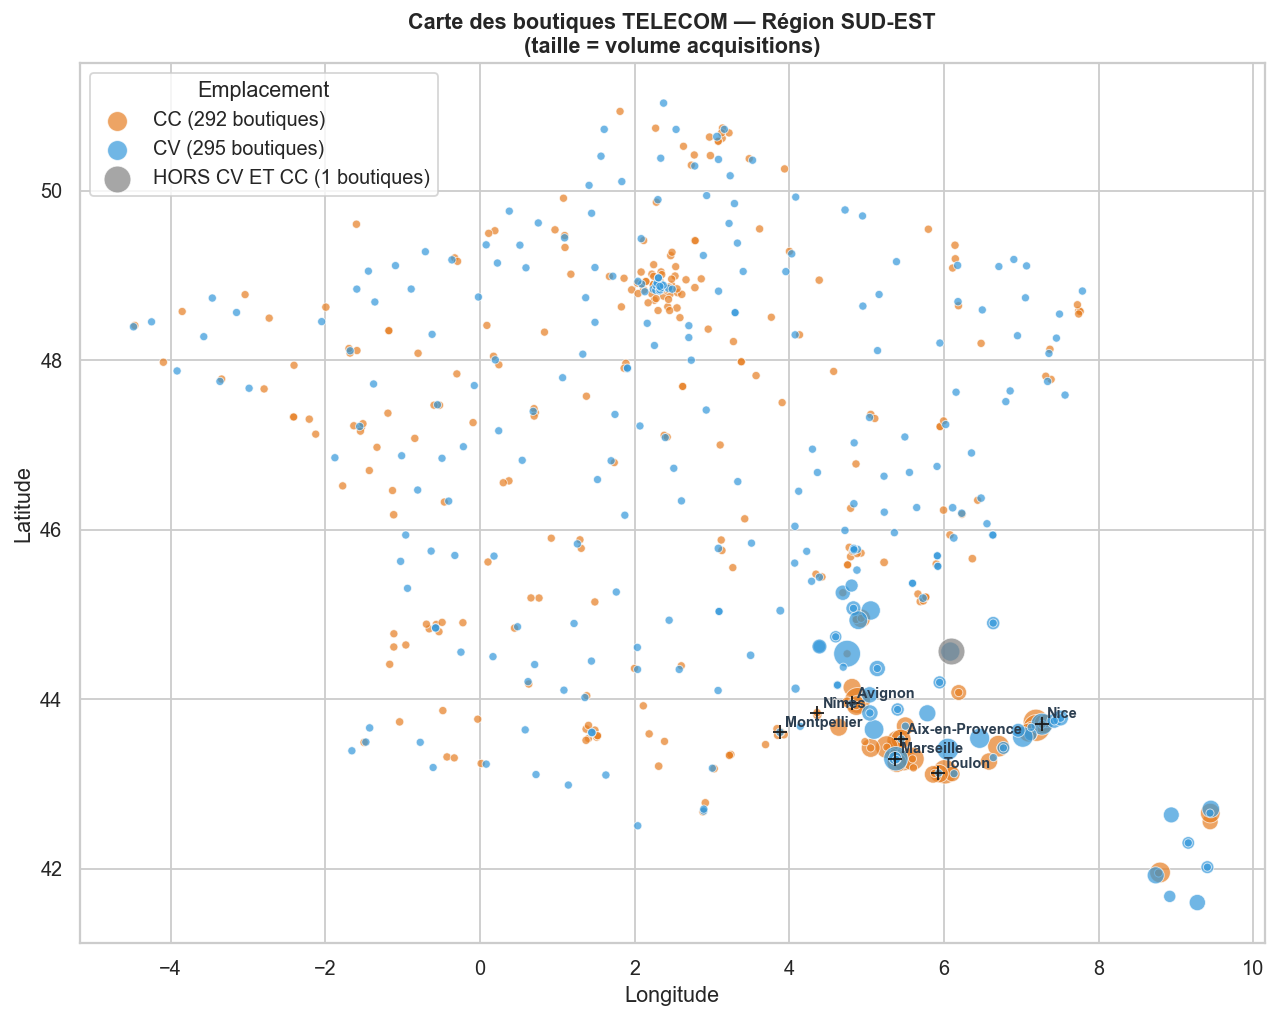

In [22]:
# Carte des boutiques SUD-EST
boutiques_geo = df.drop_duplicates('ORDER_SHOP_CD')[[
    'ORDER_SHOP_CD', 'latitude', 'longitude', 'Emplacement_PDV', 'Surface_COMMERC'
]].dropna(subset=['latitude', 'longitude'])

# Ajouter le volume
boutiques_geo = boutiques_geo.merge(
    df.groupby('ORDER_SHOP_CD').size().reset_index(name='volume'),
    on='ORDER_SHOP_CD'
)

print(f"Boutiques avec coordonnées : {len(boutiques_geo)}")

fig, ax = plt.subplots(figsize=(10, 8))
colors = {'CC': '#e67e22', 'CV': '#3498db'}
for emp, grp in boutiques_geo.groupby('Emplacement_PDV'):
    sc = ax.scatter(
        grp['longitude'], grp['latitude'],
        c=colors.get(emp, 'gray'),
        s=grp['volume'] / grp['volume'].max() * 200 + 20,
        alpha=0.7, label=f'{emp} ({len(grp)} boutiques)', edgecolors='white', linewidth=0.5
    )

# Villes clés SUD-EST
villes_cles = {
    'Marseille': (43.296, 5.370), 'Nice': (43.710, 7.262),
    'Toulon': (43.124, 5.928), 'Montpellier': (43.611, 3.876),
    'Avignon': (43.949, 4.806), 'Nîmes': (43.837, 4.360),
    'Aix-en-Provence': (43.530, 5.447)
}
for ville, (lat, lon) in villes_cles.items():
    ax.annotate(ville, (lon, lat), fontsize=8, fontweight='bold',
                xytext=(3, 3), textcoords='offset points', color='#2c3e50')
    ax.plot(lon, lat, 'k+', markersize=8)

ax.set_title('Carte des boutiques TELECOM — Région SUD-EST\n(taille = volume acquisitions)', fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Emplacement', loc='upper left')
plt.tight_layout()
plt.savefig('4d_carte_boutiques.png', bbox_inches='tight')
plt.show()

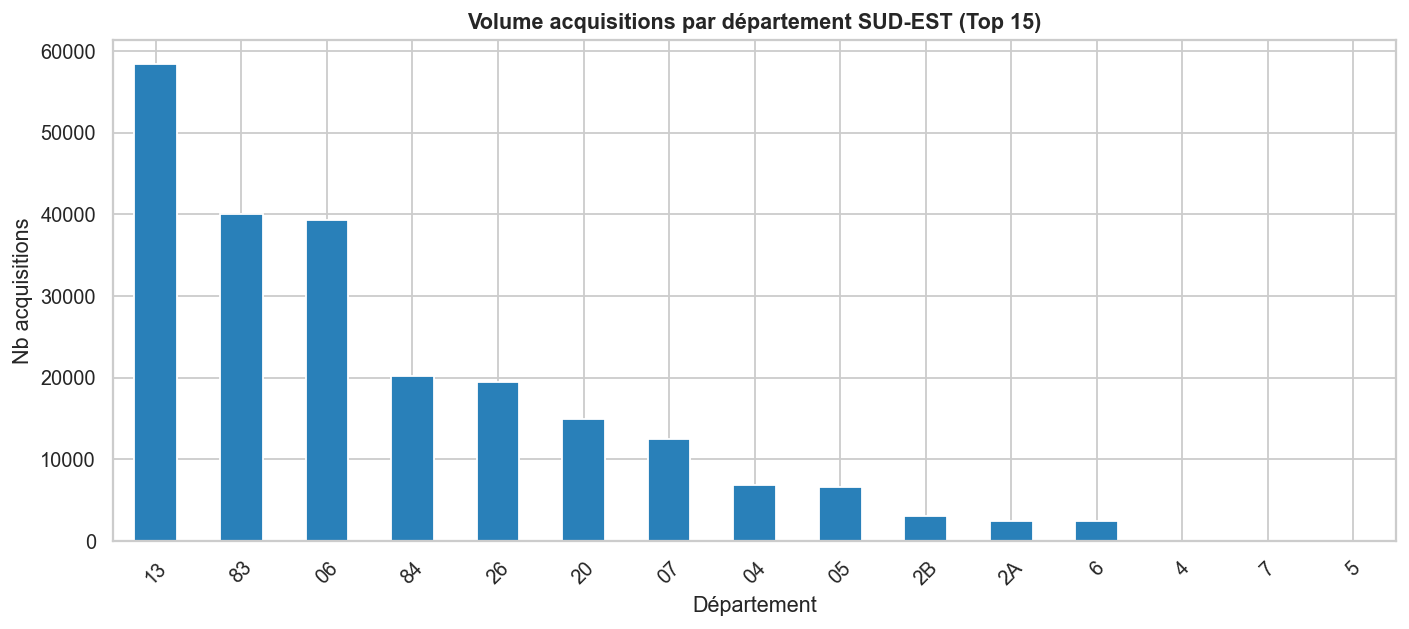

In [23]:
# Répartition géographique par département
dept_vol = df.groupby('DEPRTMNT_ID').size().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
dept_vol.plot(kind='bar', ax=ax, color='#2980b9')
ax.set_title('Volume acquisitions par département SUD-EST (Top 15)', fontweight='bold')
ax.set_xlabel('Département')
ax.set_ylabel('Nb acquisitions')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('4d_dept.png', bbox_inches='tight')
plt.show()

## Conclusion Etape 4 — Points clés

| Analyse | Enseignement |
|---|---|
| LINE_TYPE | Répartition variable — à confirmer avec les données |
| Temporel | Tendance globale visible sur la courbe mensuelle |
| Boutiques | Forte hétérogénéité entre Top et Flop boutiques |
| Age clients | Profil vieillissant vs jeune selon les boutiques |
| CC vs CV | Performances comparées documentées |
| Spatial | Concentration géographique sur littoral |

**→ Prochaine étape : Création des nouvelles variables (Etape 5)**